# GTZAN — MOO + TSK v23: Comparativo de Algoritmos Multiobjetivo com Agregador Fuzzy

## Objetivo
Comparar **3 algoritmos de otimização multiobjetivo** aplicados ao mesmo problema de otimização de hiperparâmetros do GTZAN, cada um rodado **com** e **sem** o Agregador Fuzzy (TSK). A evidência principal é a participação de cada variante na fronteira de Pareto unificada final.

## Algoritmos comparados

| # | Algoritmo | Tipo | Estratégia de seleção | Referência |
|---|---|---|---|---|
| 1 | **NSGA-II** | Dominância de Pareto + crowding | Ranking + distância de aglomeração | Deb et al. 2002 |
| 2 | **NSGA-III** | Dominância de Pareto + pontos de referência | Ranking + projeção em hiperplano | Deb & Jain 2014 |
| 3 | **MOEA/D** | Decomposição por pesos | Otimização escalarizada por vizinhança | Zhang & Li 2007 |

## Estrutura experimental
- Cada algoritmo roda **2 vezes**: com Fuzzy (4 objetivos: `[1-acc, custo, 1-auroc, 1-fis_quality]`) e sem Fuzzy (3 objetivos: `[1-acc, custo, 1-auroc]`).
- Total: **6 rodadas independentes**.
- Cache global compartilhado — soluções já avaliadas são reutilizadas entre rodadas.
- Fronteira de Pareto unificada final calculada no espaço original de 3 objetivos para todas as 10 rodadas juntas.
- Análise por algoritmo: quantas NDS finais cada um contribuiu, com e sem fuzzy.

## Por que esses algoritmos?
- **NSGA-II** → baseline clássico (crowding distance).
- **NSGA-III** → melhor para muitos objetivos (≥3); troca crowding por pontos de referência estruturados.
- **MOEA/D** → decompõe o problema em subproblemas escalares; excelente para distribuição uniforme.

In [1]:
# [0] Instalação
# !pip install torch torchvision pymoo scikit-learn numpy pandas matplotlib scipy librosa soundfile

In [1]:
# [1] Imports
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split, Dataset
import torchvision.models as models
from torchvision import transforms
from PIL import Image
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random, time, gc, json, hashlib, warnings
from pathlib import Path
from itertools import product as iproduct
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, classification_report
)
# ── Algoritmos MOO ──
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2  import NSGA2
from pymoo.algorithms.moo.nsga3  import NSGA3
from pymoo.algorithms.moo.moead  import MOEAD
from pymoo.algorithms.moo.sms    import SMSEMOA
from pymoo.algorithms.moo.rnsga2 import RNSGA2
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm   import PM
from pymoo.operators.sampling.rnd  import FloatRandomSampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination
from pymoo.core.callback import Callback
from pymoo.indicators.hv import HV
from pymoo.util.ref_dirs import get_reference_directions
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Device: cuda
  GPU : NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM: 4.3 GB


In [2]:
# [2] Configuração
DATA_ROOT    = r'C:\Users\caio.grasso\OneDrive - RIO ENERGY PARTICIPAÇÕES S.A\Área de Trabalho\Mestrado\data\gtzan\genres_original'  # <- AJUSTE AQUI
PNG_MODE     = False
DATASET_NAME = 'gtzan_v23'

# ── Hiperparâmetros do loop evolutivo — IGUAIS para todos os algoritmos (comparação justa) ──
POP     = 30   # tamanho de população
GEN     = 15   # gerações
SBX_ETA = 10
PM_ETA  = 15

BASE_DIR  = Path('results') / DATASET_NAME
CKPT_DIR  = BASE_DIR / 'checkpoints'
PLOTS_DIR = BASE_DIR / 'plots'
LOGS_DIR  = BASE_DIR / 'logs'
CSV_DIR   = BASE_DIR / 'csv'
for d in [CKPT_DIR, PLOTS_DIR, LOGS_DIR, CSV_DIR]: d.mkdir(parents=True, exist_ok=True)

# ── Algoritmos que serão executados ──
# Cada entrada: (tag, label_legivel)
ALGORITHMS = [
    ('nsga2',   'NSGA-II'),
    ('nsga3',   'NSGA-III'),
    ('moead',   'MOEA/D'),
]

# ── Variantes: com e sem fuzzy ──
VARIANTS = ['fuzzy', 'puro']

print(f'Algoritmos: {[a[1] for a in ALGORITHMS]}')
print(f'Variantes: {VARIANTS}')
print(f'Total rodadas: {len(ALGORITHMS) * len(VARIANTS)}')
print(f'pop={POP}  gen={GEN}')

Algoritmos: ['NSGA-II', 'NSGA-III', 'MOEA/D']
Variantes: ['fuzzy', 'puro']
Total rodadas: 6
pop=30  gen=15


In [3]:
# [3] Dataset GTZAN
TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
])

class GTZANWavDataset(Dataset):
    def __init__(self, root, n_mels=128, n_fft=2048, hop_length=512, fmax=8000, transform=None):
        try:
            import librosa; self._lib=librosa
        except ImportError: raise ImportError('pip install librosa soundfile')
        self.root=Path(root); self.transform=transform
        self.n_mels=n_mels; self.n_fft=n_fft; self.hop_length=hop_length; self.fmax=fmax
        self.samples=[]; self.classes=[]
        for i,d in enumerate(sorted(p for p in self.root.iterdir() if p.is_dir())):
            self.classes.append(d.name)
            for p in sorted(d.glob('*.wav')): self.samples.append((str(p),i))
        print(f'  WAV {len(self.classes)}cls {len(self.samples)}arq n_mels={n_mels} n_fft={n_fft}')
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path,label=self.samples[idx]
        try:
            y,_=self._lib.load(path,sr=22050,mono=True,duration=30.0)
            S=self._lib.feature.melspectrogram(y=y,sr=22050,n_mels=self.n_mels,
                n_fft=self.n_fft,hop_length=self.hop_length,fmax=self.fmax)
            S_db=self._lib.power_to_db(S,ref=np.max)
            mn,mx=S_db.min(),S_db.max(); S_n=(S_db-mn)/(mx-mn+1e-8)
            img=Image.fromarray((np.stack([S_n]*3,axis=2)*255).astype(np.uint8))
        except: img=Image.fromarray(np.zeros((128,128,3),dtype=np.uint8))
        if self.transform: img=self.transform(img)
        return img,label

class GTZANPNGDataset(Dataset):
    def __init__(self,root,transform=None):
        self.transform=transform; self.samples=[]; self.classes=[]
        for i,d in enumerate(sorted(p for p in Path(root).iterdir() if p.is_dir())):
            self.classes.append(d.name)
            for p in sorted(d.glob('*.png')): self.samples.append((str(p),i))
        print(f'  PNG {len(self.classes)}cls {len(self.samples)}imagens')
    def __len__(self): return len(self.samples)
    def __getitem__(self,idx):
        path,label=self.samples[idx]
        img=Image.open(path).convert('RGB')
        if self.transform: img=self.transform(img)
        return img,label

_ref = GTZANPNGDataset(DATA_ROOT,TRANSFORM) if PNG_MODE else GTZANWavDataset(DATA_ROOT,transform=TRANSFORM)
CLASSES=_ref.classes; NUM_CLASSES=len(CLASSES)
print(f'Classes ({NUM_CLASSES}): {CLASSES}')

BACKBONE_CFGS={
    0:('ResNet18',       models.resnet18,        'IMAGENET1K_V1',512),
    1:('EfficientNet-B0',models.efficientnet_b0, 'IMAGENET1K_V1',1280),
    2:('MobileNetV2',    models.mobilenet_v2,    'IMAGENET1K_V1',1280),
}
LATENCY_REF={'ResNet18':10,'EfficientNet-B0':12,'MobileNetV2':8}
LAT_MAX=max(LATENCY_REF.values()); COST_MAX=80*12

  WAV 10cls 1000arq n_mels=128 n_fft=2048
Classes (10): ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


In [4]:
# [4] Cromossomo, decode e utilitários
N_VAR=11
xl=np.array([0.0,0,20,0.0,0,0,0.1, 0,0,0.1,0])
xu=np.array([1.0,2,80,1.0,2,2,0.5, 3,2,0.5,2])
BATCH_SIZES=[32,64,128]
N_MELS_OPTS=[32,64,128,256]
N_FFT_OPTS=[512,1024,2048]
FMAX_OPTS=[4000,8000,11025]

def decode(x):
    lr=10**(np.log10(1e-4)+x[0]*(np.log10(1e-1)-np.log10(1e-4)))
    wd=10**(np.log10(1e-5)+x[3]*(np.log10(1e-2)-np.log10(1e-5)))
    n_fft=N_FFT_OPTS[int(np.clip(round(x[8]),0,2))]
    hop=max(64,int(n_fft*float(np.clip(x[9],0.1,0.5))))
    return {
        'lr':float(lr),'optimizer':int(np.clip(round(x[1]),0,2)),
        'epochs':int(np.clip(round(x[2]),20,80)),'wd':float(wd),
        'backbone_idx':int(np.clip(round(x[4]),0,2)),
        'batch_size':BATCH_SIZES[int(np.clip(round(x[5]),0,2))],
        'dropout':float(np.clip(x[6],0.1,0.5)),
        'n_mels':N_MELS_OPTS[int(np.clip(round(x[7]),0,3))],
        'n_fft':n_fft,'hop_length':hop,
        'fmax':FMAX_OPTS[int(np.clip(round(x[10]),0,2))],
    }

def xkey(x): return hashlib.md5(np.array(x,dtype=np.float64).tobytes()).hexdigest()

HV_REF3=np.array([1.1,1.1,1.1])
HV_REF4=np.array([1.1,1.1,1.1,1.1])

def pareto_filter(F):
    n=len(F); dom=np.zeros(n,dtype=bool)
    for i in range(n):
        for j in range(n):
            if i==j: continue
            if np.all(F[j]<=F[i]) and np.any(F[j]<F[i]): dom[i]=True; break
    return ~dom

def calc_hv(F_arc, ref=None):
    r=ref if ref is not None else HV_REF3
    return float(HV(ref_point=r).do(F_arc))

def compute_cost(m):
    return float(np.clip(m['params']['epochs']*LATENCY_REF[m['backbone']]/COST_MAX,0,1))

N_MELS_MAX=256; N_FFT_MAX=2048
def spec_cost_norm(p):
    return float((p['n_mels']/N_MELS_MAX)*(p['n_fft']/N_FFT_MAX))

EP_MIN,EP_MAX=20,80
print(f'Cromossomo: {N_VAR} genes | objetivos brutos: [1-acc, custo, 1-auroc]')

Cromossomo: 11 genes | objetivos brutos: [1-acc, custo, 1-auroc]


In [5]:
# [5] LinearHead + fast_eval (cache global compartilhado entre TODAS as rodadas)
class LinearHead(nn.Module):
    def __init__(self,feat_dim,num_classes,dropout=0.4):
        super().__init__()
        self.net=nn.Sequential(
            nn.Linear(feat_dim,512),nn.BatchNorm1d(512),nn.ReLU(),nn.Dropout(dropout),
            nn.Linear(512,256),nn.BatchNorm1d(256),nn.ReLU(),nn.Dropout(dropout*0.75),
            nn.Linear(256,num_classes)
        )
    def forward(self,x): return self.net(x)

# Cache GLOBAL — compartilhado entre TODOS os algoritmos e variantes.
# Correto metodologicamente: a avaliação é determinística; reutilizá-la
# não favorece nenhum algoritmo específico.
EVAL_CACHE = {}

def fast_eval(x_vec):
    key=xkey(x_vec)
    if key in EVAL_CACHE:
        m=EVAL_CACHE[key]; print(f"  CACHE {m['backbone']:18s}  acc={m['accuracy']:.4f}",flush=True)
        return m
    params=decode(x_vec)
    bidx=params['backbone_idx']; bname=BACKBONE_CFGS[bidx][0]; feat_dim=BACKBONE_CFGS[bidx][3]
    if PNG_MODE:
        full_ds=GTZANPNGDataset(DATA_ROOT,TRANSFORM)
    else:
        full_ds=GTZANWavDataset(DATA_ROOT,params['n_mels'],params['n_fft'],
                                 params['hop_length'],params['fmax'],TRANSFORM)
    g=torch.Generator().manual_seed(SEED)
    n=len(full_ds); n_te=max(int(.15*n),50); n_va=max(int(.15*n),50); n_tr=n-n_va-n_te
    tr_ds,va_ds,te_ds=random_split(full_ds,[n_tr,n_va,n_te],generator=g)
    print(f"  TRAIN {bname:18s} lr={params['lr']:.2e} ep={params['epochs']} "
          f"[{params['n_mels']}mel/{params['n_fft']}fft]",flush=True)
    def _ext(ds):
        base=BACKBONE_CFGS[bidx][1](weights=BACKBONE_CFGS[bidx][2]).to(device)
        if hasattr(base,'fc'):           base.fc=nn.Identity()
        elif hasattr(base,'classifier'): base.classifier=nn.Identity()
        base.eval()
        ldr=DataLoader(ds,64,shuffle=False,num_workers=0)
        fs,ls=[],[]
        with torch.no_grad():
            for X,y in ldr:
                fs.append(base(X.to(device)).cpu())
                ls.append(y if torch.is_tensor(y) else torch.tensor(y))
        del base; torch.cuda.empty_cache(); gc.collect()
        return torch.cat(fs),torch.cat(ls)
    f_tr,l_tr=_ext(tr_ds); f_va,l_va=_ext(va_ds); f_te,l_te=_ext(te_ds)
    seed=int(key[:8],16)%(2**31); torch.manual_seed(seed); np.random.seed(seed%(2**32))
    bs=params['batch_size']; g2=torch.Generator(); g2.manual_seed(seed)
    tr_ld=DataLoader(TensorDataset(f_tr,l_tr),bs,shuffle=True,generator=g2)
    va_ld=DataLoader(TensorDataset(f_va,l_va),bs,shuffle=False)
    model=LinearHead(feat_dim,NUM_CLASSES,params['dropout']).to(device)
    crit=nn.CrossEntropyLoss(label_smoothing=0.1)
    kw={'lr':params['lr'],'weight_decay':params['wd']}
    if params['optimizer']==2: kw.update({'momentum':0.9,'nesterov':True})
    opt={0:optim.Adam,1:optim.AdamW,2:optim.SGD}[params['optimizer']](model.parameters(),**kw)
    sched=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=params['epochs'],eta_min=params['lr']*0.01)
    best_loss,pat=float('inf'),0
    for _ in range(params['epochs']):
        model.train()
        for X,y in tr_ld:
            X,y=X.to(device),y.to(device)
            opt.zero_grad(); crit(model(X),y).backward(); opt.step()
        sched.step()
        model.eval()
        with torch.no_grad():
            vl=sum(crit(model(X.to(device)),y.to(device)).item() for X,y in va_ld)/len(va_ld)
        if vl<best_loss: best_loss=vl; pat=0
        else: pat+=1
        if pat>=6: break
    model.eval(); preds,labs,probs=[],[],[]
    with torch.no_grad():
        for X,y in va_ld:
            out=model(X.to(device))
            preds.extend(torch.argmax(out,1).cpu().numpy())
            labs.extend(y.numpy())
            probs.extend(torch.softmax(out,1).cpu().numpy())
    preds=np.array(preds); labs=np.array(labs); probs=np.array(probs)
    acc=float(accuracy_score(labs,preds))
    f1m=float(f1_score(labs,preds,average='macro',zero_division=0))
    prec=float(precision_score(labs,preds,average='macro',zero_division=0))
    rec=float(recall_score(labs,preds,average='macro',zero_division=0))
    try:    auroc=float(roc_auc_score(labs,probs,multi_class='ovr',average='macro'))
    except: auroc=0.5
    result={'accuracy':acc,'f1':f1m,'precision':prec,'recall':rec,
            'auroc':auroc,'fpr':1-acc,'loss':best_loss,
            'backbone':bname,'backbone_idx':bidx,'params':params,
            'model_state':{k:v.cpu() for k,v in model.state_dict().items()},'dropout':params['dropout'],
            'feat_dim':feat_dim,'f_te':f_te,'l_te':l_te}
    del model,opt,sched; gc.collect()
    EVAL_CACHE[key]=result
    print(f"        acc={acc:.4f} f1={f1m:.4f} auroc={auroc:.4f}",flush=True)
    return result

def eval_on_test(m):
    te_ld=DataLoader(TensorDataset(m['f_te'],m['l_te']),256,shuffle=False)
    model=LinearHead(m['feat_dim'],NUM_CLASSES,m.get('dropout',0.4)).to(device)
    model.load_state_dict({k:v.to(device) for k,v in m['model_state'].items()})
    model.eval(); preds,labs,probs=[],[],[]
    with torch.no_grad():
        for X,y in te_ld:
            out=model(X.to(device))
            preds.extend(torch.argmax(out,1).cpu().numpy())
            labs.extend(y.numpy()); probs.extend(torch.softmax(out,1).cpu().numpy())
    preds=np.array(preds); labs=np.array(labs); probs=np.array(probs)
    acc=float(accuracy_score(labs,preds))
    f1m=float(f1_score(labs,preds,average='macro',zero_division=0))
    try:    auroc=float(roc_auc_score(labs,probs,multi_class='ovr',average='macro'))
    except: auroc=0.5
    del model; gc.collect()
    return {'accuracy':acc,'f1':f1m,'auroc':auroc,'preds':preds,'labels':labs,'probs':probs}

print('fast_eval OK — cache global compartilhado entre os 10 algoritmos')

fast_eval OK — cache global compartilhado entre os 10 algoritmos


In [6]:
# [6] TSK Adaptativo — FIS-Eval, FIS-OOD, FIS-Perf, FIS-Sel (idêntico ao v21)
STATE_NAMES=['very_low','low','medium','high','very_high']
PROFILE={
    'acc':    [(0.00,0.65),(0.65,0.72),(0.72,0.79),(0.79,0.85),(0.85,1.00)],
    'f1':     [(0.00,0.65),(0.65,0.72),(0.72,0.79),(0.79,0.85),(0.85,1.00)],
    'auroc':  [(0.80,0.87),(0.87,0.91),(0.91,0.94),(0.94,0.97),(0.97,1.00)],
    'fpr_inv':[(0.00,0.645),(0.645,0.715),(0.715,0.785),(0.785,0.845),(0.845,1.000)],
}
def build_mfs(profile,tightness=2.5):
    c=[(lo+hi)/2 for lo,hi in profile]
    s=[max((hi-lo)/tightness,0.006) for lo,hi in profile]
    return c,s
def membership(x,cs,ss):
    return np.array([np.exp(-((x-c)**2)/(2*sg**2)) for c,sg in zip(cs,ss)])
C_ACC,S_ACC=build_mfs(PROFILE['acc']); C_F1,S_F1=build_mfs(PROFILE['f1'])
C_AU,S_AU=build_mfs(PROFILE['auroc']); C_FP,S_FP=build_mfs(PROFILE['fpr_inv'])
C_STD,S_STD=build_mfs([(0.0,0.2),(0.2,0.4),(0.4,0.6),(0.6,0.8),(0.8,1.0)],tightness=2.0)
TSK_EVAL={'very_high':(+0.20,0.55,0.45),'high':(+0.08,0.55,0.45),'medium':(0.00,0.50,0.50),'low':(-0.12,0.50,0.50),'very_low':(-0.30,0.45,0.55)}
TSK_OOD ={'very_high':(+0.12,0.50,0.50),'high':(+0.05,0.50,0.50),'medium':(0.00,0.50,0.50),'low':(-0.08,0.50,0.50),'very_low':(-0.18,0.50,0.50)}
TSK_PERF={'very_high':(+0.10,0.30,0.30,0.20,0.20),'high':(+0.04,0.30,0.30,0.20,0.20),'medium':(0.00,0.30,0.30,0.20,0.20),'low':(-0.06,0.30,0.30,0.20,0.20),'very_low':(-0.16,0.30,0.30,0.20,0.20)}
TSK_SEL ={'very_high':(+0.08,0.50,0.30,0.20),'high':(+0.03,0.50,0.30,0.20),'medium':(0.00,0.50,0.30,0.20),'low':(-0.06,0.50,0.30,0.20),'very_low':(-0.18,0.50,0.30,0.20)}
def tsk_2in(x1,x2,c1,s1,c2,s2,coeff):
    mu1=membership(x1,c1,s1); mu2=membership(x2,c2,s2); tw,twz=0.0,0.0
    for i,si in enumerate(STATE_NAMES):
        for j,sj in enumerate(STATE_NAMES):
            w=float(mu1[i]*mu2[j])
            if w<1e-12: continue
            ci=coeff[si]; cj=coeff[sj]; a0=(ci[0]+cj[0])/2; a1=(ci[1]+cj[1])/2; a2=(ci[2]+cj[2])/2
            twz+=w*(a0+a1*x1+a2*x2); tw+=w
    return float(np.clip(twz/tw,0,1)) if tw>0 else float((x1+x2)/2)
def tsk_3in(x1,x2,x3,c1,s1,c2,s2,c3,s3,coeff):
    mu1=membership(x1,c1,s1); mu2=membership(x2,c2,s2); mu3=membership(x3,c3,s3); tw,twz=0.0,0.0
    for i,si in enumerate(STATE_NAMES):
        for j,sj in enumerate(STATE_NAMES):
            for k in range(len(STATE_NAMES)):
                w=float(mu1[i]*mu2[j]*mu3[k])
                if w<1e-12: continue
                ci=coeff[si]; cj=coeff[sj]; ck=coeff[STATE_NAMES[k]]
                a0=(ci[0]+cj[0]+ck[0])/3; a1=(ci[1]+cj[1]+ck[1])/3; a2=(ci[2]+cj[2]+ck[2])/3; a3=(ci[3]+cj[3]+ck[3])/3
                twz+=w*(a0+a1*x1+a2*x2+a3*x3); tw+=w
    return float(np.clip(twz/tw,0,1)) if tw>0 else float((x1+x2+x3)/3)
def tsk_4in(x1,x2,x3,x4,c1,s1,c2,s2,c3,s3,c4,s4,coeff):
    mu1=membership(x1,c1,s1); mu2=membership(x2,c2,s2); mu3=membership(x3,c3,s3); mu4=membership(x4,c4,s4); tw,twz=0.0,0.0
    for i,si in enumerate(STATE_NAMES):
      for j,sj in enumerate(STATE_NAMES):
        for k,sk in enumerate(STATE_NAMES):
          for l_idx,sl in enumerate(STATE_NAMES):
            w=float(mu1[i]*mu2[j]*mu3[k]*mu4[l_idx])
            if w<1e-12: continue
            ci=coeff[si]; cj=coeff[sj]; ck=coeff[sk]; cl_=coeff[sl]
            a0=(ci[0]+cj[0]+ck[0]+cl_[0])/4; a1=(ci[1]+cj[1]+ck[1]+cl_[1])/4
            a2=(ci[2]+cj[2]+ck[2]+cl_[2])/4; a3=(ci[3]+cj[3]+ck[3]+cl_[3])/4; a4=(ci[4]+cj[4]+ck[4]+cl_[4])/4
            twz+=w*(a0+a1*x1+a2*x2+a3*x3+a4*x4); tw+=w
    return float(np.clip(twz/tw,0,1)) if tw>0 else float((x1+x2+x3+x4)/4)
def perf_inputs(m):
    ep=m['params']['epochs']; drop=m['params']['dropout']
    lat_b=LATENCY_REF[m['backbone']]/LAT_MAX
    lat_s=float(np.clip(1-lat_b*(ep/EP_MAX),0,1))
    comp_s=float(np.clip(1-(ep-EP_MIN)/(EP_MAX-EP_MIN),0,1))
    reg_s=float(np.clip(drop/0.5,0,1))
    spec_s=float(np.clip(1-spec_cost_norm(m['params']),0,1))
    return lat_s,comp_s,reg_s,spec_s
def fis_eval(acc,f1): return tsk_2in(acc,f1,C_ACC,S_ACC,C_F1,S_F1,TSK_EVAL)
def fis_ood(auroc,fpr_inv): return tsk_2in(auroc,fpr_inv,C_AU,S_AU,C_FP,S_FP,TSK_OOD)
def fis_perf(l,c,r,s): return tsk_4in(l,c,r,s,C_STD,S_STD,C_STD,S_STD,C_STD,S_STD,C_STD,S_STD,TSK_PERF)
def fis_sel_from_m(m):
    fe=fis_eval(m['accuracy'],m['f1'])
    fo=fis_ood(m['auroc'],1-m['fpr'])
    l,c,r,s=perf_inputs(m)
    fp=fis_perf(l,c,r,s)
    q=tsk_3in(fe,fo,fp,C_STD,S_STD,C_STD,S_STD,C_STD,S_STD,TSK_SEL)
    return q,fe,fo,fp
print('TSK OK')

TSK OK


In [7]:
# [7] Classes de problema MOO — Fuzzy (4 obj) e Puro (3 obj)
# A mesma classe é reutilizada por todos os algoritmos;
# o que muda entre as rodadas é apenas o objeto `algorithm`.

class GTZANProblemFuzzy(ElementwiseProblem):
    """4 objetivos: [1-acc, custo, 1-auroc, 1-fis_quality]."""
    def __init__(self):
        super().__init__(n_var=N_VAR,n_obj=4,n_constr=0,xl=xl,xu=xu)
    def _evaluate(self,x,out,*a,**k):
        m=fast_eval(x); q,_,_,_=fis_sel_from_m(m)
        out['F']=np.array([1.0-m['accuracy'],compute_cost(m),1.0-m['auroc'],1.0-q])

class GTZANProblemPuro(ElementwiseProblem):
    """3 objetivos brutos: [1-acc, custo, 1-auroc]."""
    def __init__(self):
        super().__init__(n_var=N_VAR,n_obj=3,n_constr=0,xl=xl,xu=xu)
    def _evaluate(self,x,out,*a,**k):
        m=fast_eval(x)
        out['F']=np.array([1.0-m['accuracy'],compute_cost(m),1.0-m['auroc']])

print('Problemas MOO OK')

Problemas MOO OK


In [8]:
# [8] Fábrica de algoritmos MOO
# Retorna um objeto pymoo Algorithm dado o tag e o número de objetivos.
# Todos usam os mesmos operadores de crossover/mutação para comparação justa.

def make_algorithm(tag, n_obj):
    """
    tag    : 'nsga2' | 'nsga3' | 'moead' | 'sms' | 'rnsga2'
    n_obj  : 3 (puro) ou 4 (fuzzy)
    Retorna: instância do algoritmo pymoo pronta para minimize().
    """
    xover = SBX(prob=0.9, eta=SBX_ETA)
    mut   = PM(eta=PM_ETA)
    samp  = FloatRandomSampling()

    if tag == 'nsga2':
        return NSGA2(
            pop_size=POP, sampling=samp, crossover=xover, mutation=mut,
            eliminate_duplicates=True
        )

    elif tag == 'nsga3':
        # Pontos de referência estruturados no simplex unitário
        # n_partitions ajustado para que o número de pontos fique ~POP
        n_part = {3: 5, 4: 4}.get(n_obj, 4)  # 3obj→21pts, 4obj→35pts
        ref_dirs = get_reference_directions('das-dennis', n_obj, n_partitions=n_part)
        return NSGA3(
            pop_size=max(POP, len(ref_dirs)),
            ref_dirs=ref_dirs,
            sampling=samp, crossover=xover, mutation=mut,
            eliminate_duplicates=True
        )

    elif tag == 'moead':
        # MOEA/D com decomposição de Tchebycheff
        # n_neighbors: vizinhança local para atualização de sub-problemas
        n_part = {3: 5, 4: 4}.get(n_obj, 4)
        ref_dirs = get_reference_directions('das-dennis', n_obj, n_partitions=n_part)
        return MOEAD(
            ref_dirs=ref_dirs,
            n_neighbors=max(5, len(ref_dirs)//5),
            prob_neighbor_mating=0.7,
            sampling=samp, crossover=xover, mutation=mut
        )

    elif tag == 'sms':
        # SMS-EMOA: remove a cada geração o indivíduo com menor
        # contribuição ao hipervolume → excelente cobertura da fronteira.
        return SMSEMOA(
            pop_size=POP, sampling=samp, crossover=xover, mutation=mut,
            eliminate_duplicates=True
        )

    elif tag == 'rnsga2':
        # R-NSGA-II: guiado por pontos de referência de interesse.
        # Definimos 3 pontos que cobrem alta acc, baixo custo e alto auroc.
        ref_points = np.array([
            [0.05, 0.10, 0.05],   # alta acc, baixo custo, alto auroc
            [0.20, 0.05, 0.10],   # acc moderada, custo mínimo
            [0.10, 0.15, 0.03],   # auroc máximo
        ])[:, :n_obj]  # ajusta dimensão para puro(3) ou fuzzy(4)
        if n_obj == 4:
            # Adicionar coluna para 1-fis_quality: alvo = baixo (0.05 → fq=0.95)
            extra = np.array([[0.05],[0.10],[0.05]])
            ref_points = np.hstack([ref_points, extra])
        return RNSGA2(
            pop_size=POP, ref_points=ref_points, epsilon=0.01,
            sampling=samp, crossover=xover, mutation=mut,
            eliminate_duplicates=True
        )

    else:
        raise ValueError(f'Algoritmo desconhecido: {tag}')

# Teste rápido
for tag, label in ALGORITHMS:
    alg3 = make_algorithm(tag, 3)
    alg4 = make_algorithm(tag, 4)
    print(f'  {label:<12} puro={type(alg3).__name__}  fuzzy={type(alg4).__name__}')
print('Fábrica de algoritmos OK')

  NSGA-II      puro=NSGA2  fuzzy=NSGA2
  NSGA-III     puro=NSGA3  fuzzy=NSGA3
  MOEA/D       puro=MOEAD  fuzzy=MOEAD
Fábrica de algoritmos OK


In [9]:
# [9] Callback genérico — funciona para qualquer algoritmo e qualquer n_obj

def extract_metrics(x_vec, origin_tag):
    key=xkey(x_vec); m=EVAL_CACHE.get(key,{})
    if not m: return None
    q,fe,fo,fp=fis_sel_from_m(m); p=m['params']
    return {
        'key':key,'origin':origin_tag,
        'backbone':m['backbone'],'accuracy':m['accuracy'],'f1':m['f1'],
        'auroc':m['auroc'],'fpr':m['fpr'],'cost':compute_cost(m),
        'fis_quality':q,'fis_eval':fe,'fis_ood':fo,'fis_perf':fp,
        'lr':p['lr'],'optimizer':p['optimizer'],'epochs':p['epochs'],
        'wd':p['wd'],'batch_size':p['batch_size'],'dropout':p['dropout'],
        'n_mels':p['n_mels'],'n_fft':p['n_fft'],
        'hop_length':p['hop_length'],'fmax':p['fmax'],
        'obj_err':1.0-m['accuracy'],'obj_cost':compute_cost(m),'obj_fpr':1.0-m['auroc'],
    }

def make_hist():
    return {'gen':[],'nds':[],'hv_gen':[],'hv_archive':[],
            'best_acc':[],'best_f1':[],'best_auroc':[],'best_cost':[],
            'pop_acc_mean':[],'pop_acc_std':[],'pop_cost_mean':[],'pop_auroc_mean':[],
            'fe_best':[],'fo_best':[],'fp_best':[],'fq_best':[],
            'fe_mean':[],'fo_mean':[],'fp_mean':[],'fq_mean':[],
            'all_acc':[],'all_f1':[],'all_auroc':[],'all_cost':[],
            'all_ep':[],'all_bk':[],'all_gen':[],'all_fq':[]}

def make_callback(hist, archive_F, archive_X, n_obj, label):
    hv_ref = HV_REF4 if n_obj == 4 else HV_REF3
    class _Cb(Callback):
        def __init__(self): super().__init__(); self.t0=time.time()
        def notify(self, algorithm):
            Fn=algorithm.opt.get('F')
            for fr,xr in zip(Fn,algorithm.opt.get('X')):
                archive_F.append(fr.copy()); archive_X.append(xr.copy())
            A=np.array(archive_F); mask=pareto_filter(A)
            try:    hv_arc=float(HV(ref_point=hv_ref).do(A[mask]))
            except: hv_arc=0.0
            gmin=Fn.min(0); gmax=Fn.max(0); rng=np.where(gmax-gmin<1e-12,1e-12,gmax-gmin)
            try:    hv_gen=float(HV(ref_point=np.ones(n_obj)*1.1).do((Fn-gmin)/rng))
            except: hv_gen=0.0
            pop_X=algorithm.pop.get('X')
            pac,pf1,pau,pco,pfe,pfo,pfp,pfq=[],[],[],[],[],[],[],[]
            for xp in pop_X:
                k=xkey(xp); m=EVAL_CACHE.get(k,{})
                if not m: continue
                q,fe,fo,fp=fis_sel_from_m(m)
                pac.append(m['accuracy']); pf1.append(m['f1'])
                pau.append(m['auroc']); pco.append(compute_cost(m))
                pfe.append(fe); pfo.append(fo); pfp.append(fp); pfq.append(q)
                pm=m['params']
                hist['all_acc'].append(m['accuracy']); hist['all_f1'].append(m['f1'])
                hist['all_auroc'].append(m['auroc']); hist['all_cost'].append(compute_cost(m))
                hist['all_ep'].append(pm['epochs']); hist['all_bk'].append(m['backbone'])
                hist['all_gen'].append(algorithm.n_gen); hist['all_fq'].append(q)
            hist['gen'].append(algorithm.n_gen); hist['nds'].append(len(Fn))
            hist['hv_gen'].append(hv_gen); hist['hv_archive'].append(hv_arc)
            if pac:
                hist['best_acc'].append(max(pac)); hist['best_f1'].append(max(pf1))
                hist['best_auroc'].append(max(pau)); hist['best_cost'].append(min(pco))
                hist['pop_acc_mean'].append(np.mean(pac)); hist['pop_acc_std'].append(np.std(pac))
                hist['pop_cost_mean'].append(np.mean(pco)); hist['pop_auroc_mean'].append(np.mean(pau))
                hist['fe_best'].append(max(pfe)); hist['fo_best'].append(max(pfo))
                hist['fp_best'].append(max(pfp)); hist['fq_best'].append(max(pfq))
                hist['fe_mean'].append(np.mean(pfe)); hist['fo_mean'].append(np.mean(pfo))
                hist['fp_mean'].append(np.mean(pfp)); hist['fq_mean'].append(np.mean(pfq))
            else:
                for k2 in ['best_acc','best_f1','best_auroc','best_cost','pop_acc_mean',
                           'pop_acc_std','pop_cost_mean','pop_auroc_mean',
                           'fe_best','fo_best','fp_best','fq_best','fe_mean','fo_mean','fp_mean','fq_mean']:
                    hist[k2].append(hist[k2][-1] if hist[k2] else 0)
            t=(time.time()-self.t0)/60
            eta=t/algorithm.n_gen*(GEN-algorithm.n_gen) if algorithm.n_gen>0 else 0
            acc_now=1-Fn[:,0].min() if len(Fn) else 0
            fq_now=max(pfq) if pfq else 0
            print(f"  [{label:<18}] Gen {algorithm.n_gen:2d}/{GEN}  "
                  f"NDS={len(Fn):2d}  acc={acc_now:.4f}  "
                  f"fq={fq_now:.3f}  HV={hv_arc:.4f}  [{t:.1f}min ETA:{eta:.0f}min]",flush=True)
    return _Cb()

print('Callback genérico OK')

Callback genérico OK


In [10]:
# [10] LOOP PRINCIPAL — executa todas as 10 rodadas
#
# Estrutura de resultados:
#   RESULTS[tag][variant] = {
#       'archive_F', 'archive_X',   # todas as soluções encontradas
#       'pF', 'pX',                 # NDS do arquivo
#       'hv_final',                 # HV final
#       'hist',                     # histórico por geração
#       'cache_snapshot',           # snapshot do EVAL_CACHE após a rodada
#   }

RESULTS = {tag: {} for tag, _ in ALGORITHMS}

for tag, label in ALGORITHMS:
    for variant in VARIANTS:
        is_fuzzy = (variant == 'fuzzy')
        n_obj    = 4 if is_fuzzy else 3
        hv_ref   = HV_REF4 if is_fuzzy else HV_REF3
        prob     = GTZANProblemFuzzy() if is_fuzzy else GTZANProblemPuro()
        run_lbl  = f'{label} ({"Fuzzy" if is_fuzzy else "Puro"})'

        print('\n' + '='*70)
        print(f'  RODADA: {run_lbl}')
        print(f'  Objetivos: {n_obj}  |  pop={POP}  gen={GEN}')
        print('='*70 + '\n')

        archive_F = []; archive_X = []
        hist      = make_hist()

        alg = make_algorithm(tag, n_obj)

        res = minimize(
            prob, alg, get_termination('n_gen', GEN),
            callback=make_callback(hist, archive_F, archive_X, n_obj, run_lbl),
            seed=SEED, save_history=False, verbose=False
        )

        A    = np.array(archive_F)
        mask = pareto_filter(A)
        pF   = A[mask]
        pX   = np.array(archive_X)[mask]
        try:    hv_fin = float(HV(ref_point=hv_ref).do(pF))
        except: hv_fin = 0.0

        RESULTS[tag][variant] = {
            'archive_F': archive_F, 'archive_X': archive_X,
            'pF': pF, 'pX': pX,
            'hv_final': hv_fin,
            'hist': hist,
            'cache_snapshot': dict(EVAL_CACHE),
            'n_obj': n_obj,
        }

        print(f'\n  ✓ {run_lbl}: NDS={mask.sum()}  HV={hv_fin:.6f}  Cache total={len(EVAL_CACHE)}')

print(f'\n\n=== TODAS AS RODADAS CONCLUÍDAS ===')
print(f'Avaliações únicas no cache: {len(EVAL_CACHE)}')


  RODADA: NSGA-II (Fuzzy)
  Objetivos: 4  |  pop=30  gen=15

  WAV 10cls 1000arq n_mels=128 n_fft=512
  TRAIN ResNet18           lr=2.10e-02 ep=72 el/512fft]
        acc=0.6400 f1=0.6583 auroc=0.9180
  WAV 10cls 1000arq n_mels=128 n_fft=1024
  TRAIN ResNet18           lr=6.03e-02 ep=69 el/1024fft]
        acc=0.7000 f1=0.7050 auroc=0.9449
  WAV 10cls 1000arq n_mels=128 n_fft=1024
  TRAIN EfficientNet-B0    lr=8.17e-02 ep=67 el/1024fft]
        acc=0.6533 f1=0.6416 auroc=0.9198
  WAV 10cls 1000arq n_mels=64 n_fft=2048
  TRAIN EfficientNet-B0    lr=1.29e-03 ep=31 el/2048fft]
        acc=0.6733 f1=0.6750 auroc=0.9409
  WAV 10cls 1000arq n_mels=32 n_fft=2048
  TRAIN EfficientNet-B0    lr=3.14e-02 ep=43 el/2048fft]
        acc=0.5733 f1=0.5868 auroc=0.9124
  WAV 10cls 1000arq n_mels=128 n_fft=2048
  TRAIN ResNet18           lr=2.20e-02 ep=54 el/2048fft]
        acc=0.7333 f1=0.7495 auroc=0.9415
  WAV 10cls 1000arq n_mels=64 n_fft=512
  TRAIN ResNet18           lr=4.76e-03 ep=22 el/512fft]


In [11]:
# [11] Construção dos DataFrames por rodada e fronteira unificada global

all_rows = []  # todas as soluções NDS de todas as rodadas
df_per_run = {}  # {(tag, variant): DataFrame}

for tag, label in ALGORITHMS:
    for variant in VARIANTS:
        r = RESULTS[tag][variant]
        origin_tag = f'{label} ({"Fuzzy" if variant=="fuzzy" else "Puro"})'
        rows = []
        seen = set()
        for x in r['pX']:
            k = xkey(x)
            if k in seen: continue
            seen.add(k)
            row = extract_metrics(x, origin_tag)
            if row:
                row['algorithm'] = label
                row['variant']   = variant
                rows.append(row)
        df = pd.DataFrame(rows)
        df_per_run[(tag, variant)] = df
        all_rows.extend(rows)

df_all = pd.DataFrame(all_rows)

# ── Fronteira Pareto UNIFICADA (espaço original 3 objetivos) ──
# Remove duplicatas por chave antes de calcular dominância
df_unique = df_all.drop_duplicates(subset='key', keep='first').copy().reset_index(drop=True)
F_all = df_unique[['obj_err','obj_cost','obj_fpr']].values
nds_mask = pareto_filter(F_all)
df_unified   = df_unique[nds_mask].copy().reset_index(drop=True)
df_dominated = df_unique[~nds_mask].copy().reset_index(drop=True)

print(f'Soluções únicas avaliadas: {len(df_unique)}')
print(f'Fronteira Pareto Unificada: {len(df_unified)} NDS')
print(f'Dominadas: {len(df_dominated)}')
print()
print('NDS por rodada (origin):')
print(df_unified['origin'].value_counts().to_string())
print()
print('NDS por algoritmo (independente de variante):')
print(df_unified['algorithm'].value_counts().to_string())
print()
print('NDS por variante (fuzzy vs puro):')
print(df_unified['variant'].value_counts().to_string())

Soluções únicas avaliadas: 47
Fronteira Pareto Unificada: 12 NDS
Dominadas: 35

NDS por rodada (origin):
origin
NSGA-II (Fuzzy)     5
NSGA-III (Fuzzy)    4
MOEA/D (Puro)       2
NSGA-III (Puro)     1

NDS por algoritmo (independente de variante):
algorithm
NSGA-II     5
NSGA-III    5
MOEA/D      2

NDS por variante (fuzzy vs puro):
variant
fuzzy    9
puro     3


In [12]:
# [12] Tabela comparativa de HV final e NDS por rodada

rows_hv = []
for tag, label in ALGORITHMS:
    for variant in VARIANTS:
        r = RESULTS[tag][variant]
        df_run = df_per_run[(tag, variant)]
        # Quantas soluções desta rodada ficaram na fronteira unificada
        keys_run = set(df_run['key'].values)
        n_in_unified = df_unified['key'].isin(keys_run).sum()
        rows_hv.append({
            'Algoritmo': label,
            'Variante': 'Fuzzy' if variant=='fuzzy' else 'Puro',
            'N_obj': r['n_obj'],
            'HV_final': round(r['hv_final'], 6),
            'NDS_proprio': len(df_run),
            'NDS_na_unificada': int(n_in_unified),
            'Pct_unificada': round(100*n_in_unified/max(len(df_unified),1), 1),
            'Acc_media': round(df_run['accuracy'].mean()*100, 2) if len(df_run) else 0,
            'F1_media':  round(df_run['f1'].mean()*100, 2)       if len(df_run) else 0,
            'AUROC_media': round(df_run['auroc'].mean(), 4)       if len(df_run) else 0,
            'Custo_medio': round(df_run['cost'].mean(), 4)        if len(df_run) else 0,
            'FQ_media':  round(df_run['fis_quality'].mean(), 4)  if len(df_run) else 0,
        })

df_summary = pd.DataFrame(rows_hv).sort_values(['NDS_na_unificada','HV_final'], ascending=[False,False])
df_summary.to_csv(str(CSV_DIR/'resumo_algoritmos.csv'), index=False)

print('=== TABELA COMPARATIVA ===')
print(df_summary.to_string(index=False))

=== TABELA COMPARATIVA ===
Algoritmo Variante  N_obj  HV_final  NDS_proprio  NDS_na_unificada  Pct_unificada  Acc_media  F1_media  AUROC_media  Custo_medio  FQ_media
  NSGA-II    Fuzzy      4  0.849607           10                 5           41.7      77.00     77.32       0.9660       0.3323    0.8543
 NSGA-III    Fuzzy      4  0.912470            7                 4           33.3      73.05     73.40       0.9524       0.1935    0.7871
   MOEA/D     Puro      3  0.822295            5                 2           16.7      71.07     71.48       0.9467       0.2667    0.7111
 NSGA-III     Puro      3  0.856458            4                 1            8.3      77.00     77.70       0.9631       0.2188    0.8753
  NSGA-II     Puro      3  0.871886           18                 0            0.0      72.56     72.84       0.9466       0.2294    0.7746
   MOEA/D    Fuzzy      4  0.773376            3                 0            0.0      71.56     71.61       0.9406       0.2125    0.7865


In [13]:
# [13] Salvar todos os CSVs
df_unique['is_nds'] = nds_mask
df_unique.to_csv(str(CSV_DIR/'todas_solucoes_unicas.csv'), index=False)
df_unified.to_csv(str(CSV_DIR/'pareto_unificado.csv'), index=False)

for (tag, variant), df in df_per_run.items():
    _, label = next(x for x in ALGORITHMS if x[0]==tag)
    fname = f'nds_{tag}_{variant}.csv'
    df.to_csv(str(CSV_DIR/fname), index=False)

print(f'CSVs salvos em {CSV_DIR}/')
for f in sorted(CSV_DIR.iterdir()): print(f'  {f.name}')

CSVs salvos em results\gtzan_v23\csv/
  nds_moead_fuzzy.csv
  nds_moead_puro.csv
  nds_nsga2_fuzzy.csv
  nds_nsga2_puro.csv
  nds_nsga3_fuzzy.csv
  nds_nsga3_puro.csv
  pareto_unificado.csv
  resumo_algoritmos.csv
  todas_solucoes_unicas.csv


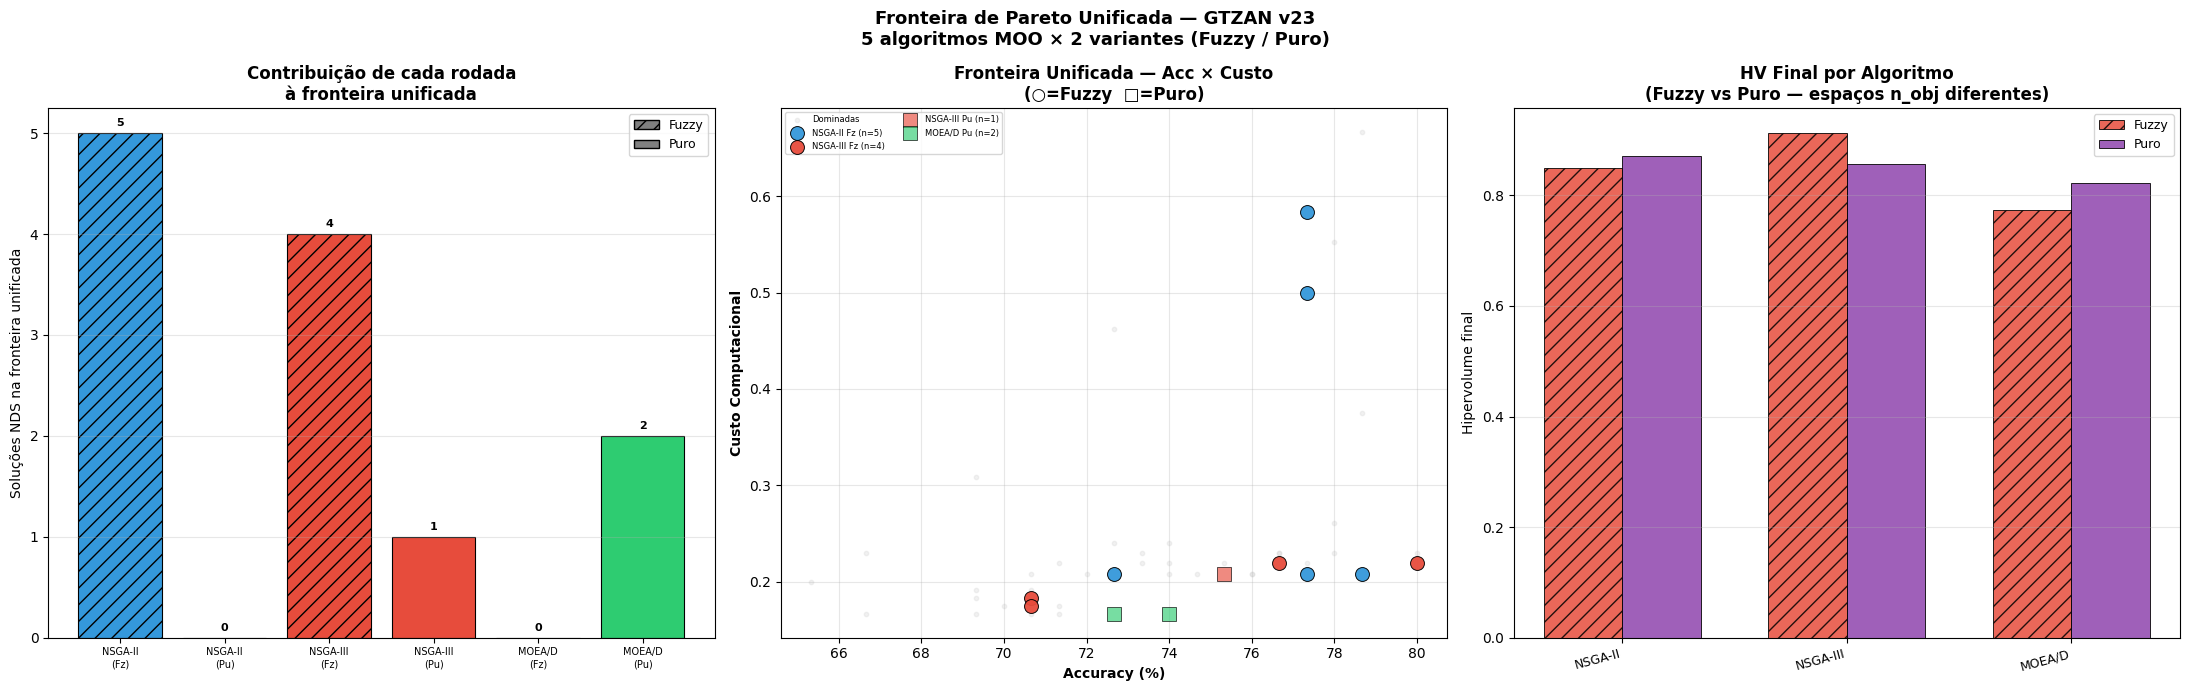

Salvo: results\gtzan_v23\plots\fig_comparativo_algoritmos.png


In [14]:
# [14] Gráfico 1 — NDS na fronteira unificada: por algoritmo + variante

ALG_COLORS = {
    'NSGA-II':   '#3498db',
    'NSGA-III':  '#e74c3c',
    'MOEA/D':    '#2ecc71',
    'SMS-EMOA':  '#f39c12',
    'R-NSGA-II': '#9b59b6',
}
VAR_HATCH = {'fuzzy': '//', 'puro': ''}
VAR_ALPHA = {'fuzzy': 0.95, 'puro': 0.65}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
plt.suptitle('Fronteira de Pareto Unificada — GTZAN v23\n'
             '5 algoritmos MOO × 2 variantes (Fuzzy / Puro)', fontsize=13, fontweight='bold')

# ── [A] Barras: NDS na fronteira unificada por rodada ──
ax = axes[0]
labels_bar = []
counts_bar = []
colors_bar = []
hatch_bar  = []
for tag, label in ALGORITHMS:
    for variant in VARIANTS:
        df_run = df_per_run[(tag, variant)]
        keys_run = set(df_run['key'].values)
        n = int(df_unified['key'].isin(keys_run).sum())
        labels_bar.append(f'{label}\n({"Fz" if variant=="fuzzy" else "Pu"})')
        counts_bar.append(n)
        colors_bar.append(ALG_COLORS[label])
        hatch_bar.append(VAR_HATCH[variant])
x_pos = np.arange(len(labels_bar))
bars = ax.bar(x_pos, counts_bar, color=colors_bar,
              edgecolor='k', lw=0.8,
              hatch=hatch_bar)
for bar, cnt in zip(bars, counts_bar):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+.05,
            str(cnt), ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_xticks(x_pos); ax.set_xticklabels(labels_bar, fontsize=7)
ax.set_ylabel('Soluções NDS na fronteira unificada')
ax.set_title('Contribuição de cada rodada\nà fronteira unificada', fontweight='bold')
# Legenda hatch
p1 = mpatches.Patch(facecolor='gray', hatch='//', label='Fuzzy', edgecolor='k')
p2 = mpatches.Patch(facecolor='gray', hatch='',   label='Puro',  edgecolor='k')
ax.legend(handles=[p1,p2], fontsize=9); ax.grid(alpha=0.3, axis='y')

# ── [B] Scatter: acc × custo, cor = algoritmo, marker = variante ──
ax = axes[1]
ax.scatter(df_dominated['accuracy']*100, df_dominated['cost'],
           c='lightgray', s=10, alpha=0.3, zorder=1, label='Dominadas')
for tag, label in ALGORITHMS:
    for variant, mk in [('fuzzy','o'),('puro','s')]:
        sub = df_unified[df_unified['origin'] == f'{label} ({"Fuzzy" if variant=="fuzzy" else "Puro"})']
        if len(sub)==0: continue
        ax.scatter(sub['accuracy']*100, sub['cost'],
                   c=ALG_COLORS[label], s=100, edgecolors='k', lw=0.7,
                   marker=mk, alpha=VAR_ALPHA[variant], zorder=4,
                   label=f'{label} {"Fz" if variant=="fuzzy" else "Pu"} (n={len(sub)})')
ax.set_xlabel('Accuracy (%)', fontweight='bold')
ax.set_ylabel('Custo Computacional', fontweight='bold')
ax.set_title('Fronteira Unificada — Acc × Custo\n(○=Fuzzy  □=Puro)', fontweight='bold')
ax.legend(fontsize=6, ncol=2); ax.grid(alpha=0.3)

# ── [C] HV final por rodada — barras agrupadas ──
ax = axes[2]
alg_labels = [label for _, label in ALGORITHMS]
x_alg = np.arange(len(alg_labels)); w = 0.35
for i, variant in enumerate(VARIANTS):
    hvs = [RESULTS[tag][variant]['hv_final'] for tag, _ in ALGORITHMS]
    ax.bar(x_alg + (i-.5)*w, hvs, width=w,
           label=f'Fuzzy' if variant=='fuzzy' else 'Puro',
           color=['#e74c3c' if variant=='fuzzy' else '#8e44ad']*len(hvs),
           hatch=VAR_HATCH[variant], edgecolor='k', lw=0.7, alpha=0.85)
ax.set_xticks(x_alg); ax.set_xticklabels(alg_labels, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Hipervolume final')
ax.set_title('HV Final por Algoritmo\n(Fuzzy vs Puro — espaços n_obj diferentes)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
p_ = PLOTS_DIR/'fig_comparativo_algoritmos.png'
plt.savefig(str(p_), dpi=200, bbox_inches='tight'); plt.show()
print(f'Salvo: {p_}')

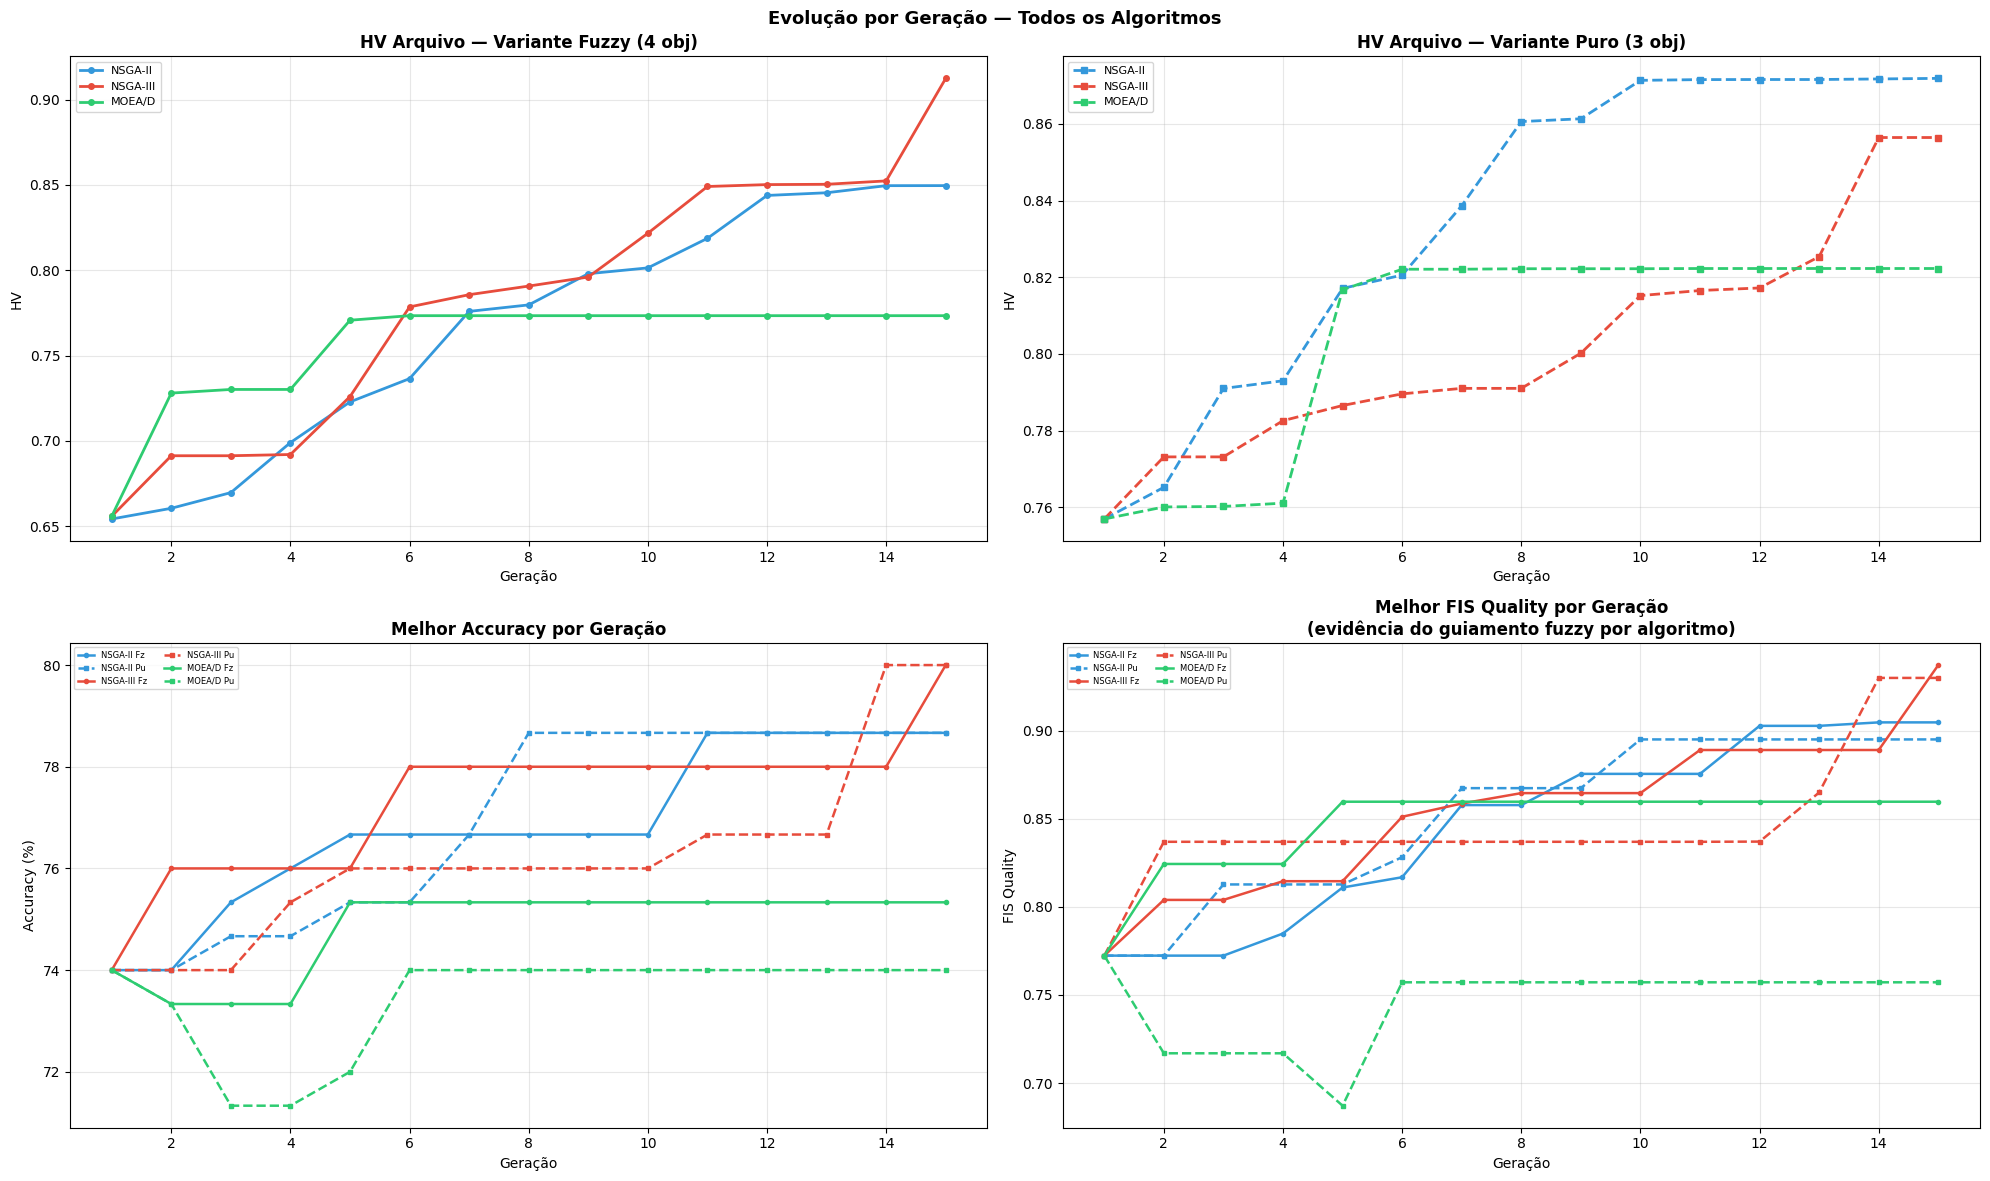

Salvo: results\gtzan_v23\plots\fig_evolucao_algoritmos.png


In [15]:
# [15] Gráfico 2 — Evolução do HV e Best Acc por geração (todos os algoritmos)

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
plt.suptitle('Evolução por Geração — Todos os Algoritmos', fontsize=13, fontweight='bold')

LS = {'fuzzy': '-', 'puro': '--'}
MK = {'fuzzy': 'o', 'puro': 's'}

# [A] HV arquivo — Fuzzy
ax = axes[0,0]
for tag, label in ALGORITHMS:
    h = RESULTS[tag]['fuzzy']['hist']
    if h['gen']:
        ax.plot(h['gen'], h['hv_archive'], color=ALG_COLORS[label],
                ls='-', marker='o', ms=4, lw=2, label=label)
ax.set_title('HV Arquivo — Variante Fuzzy (4 obj)', fontweight='bold')
ax.set_xlabel('Geração'); ax.set_ylabel('HV')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# [B] HV arquivo — Puro
ax = axes[0,1]
for tag, label in ALGORITHMS:
    h = RESULTS[tag]['puro']['hist']
    if h['gen']:
        ax.plot(h['gen'], h['hv_archive'], color=ALG_COLORS[label],
                ls='--', marker='s', ms=4, lw=2, label=label)
ax.set_title('HV Arquivo — Variante Puro (3 obj)', fontweight='bold')
ax.set_xlabel('Geração'); ax.set_ylabel('HV')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# [C] Melhor Accuracy — Fuzzy vs Puro por algoritmo
ax = axes[1,0]
for tag, label in ALGORITHMS:
    for variant in VARIANTS:
        h = RESULTS[tag][variant]['hist']
        if h['gen']:
            ax.plot(h['gen'], [v*100 for v in h['best_acc']],
                    color=ALG_COLORS[label], ls=LS[variant],
                    marker=MK[variant], ms=3, lw=1.8,
                    label=f'{label} {"Fz" if variant=="fuzzy" else "Pu"}')
ax.set_title('Melhor Accuracy por Geração', fontweight='bold')
ax.set_xlabel('Geração'); ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=6, ncol=2); ax.grid(alpha=0.3)

# [D] FIS Quality — Fuzzy vs Puro
ax = axes[1,1]
for tag, label in ALGORITHMS:
    for variant in VARIANTS:
        h = RESULTS[tag][variant]['hist']
        if h['gen'] and h['fq_best']:
            ax.plot(h['gen'], h['fq_best'],
                    color=ALG_COLORS[label], ls=LS[variant],
                    marker=MK[variant], ms=3, lw=1.8,
                    label=f'{label} {"Fz" if variant=="fuzzy" else "Pu"}')
ax.set_title('Melhor FIS Quality por Geração\n(evidência do guiamento fuzzy por algoritmo)', fontweight='bold')
ax.set_xlabel('Geração'); ax.set_ylabel('FIS Quality')
ax.legend(fontsize=6, ncol=2); ax.grid(alpha=0.3)

plt.tight_layout()
p_ = PLOTS_DIR/'fig_evolucao_algoritmos.png'
plt.savefig(str(p_), dpi=200, bbox_inches='tight'); plt.show()
print(f'Salvo: {p_}')

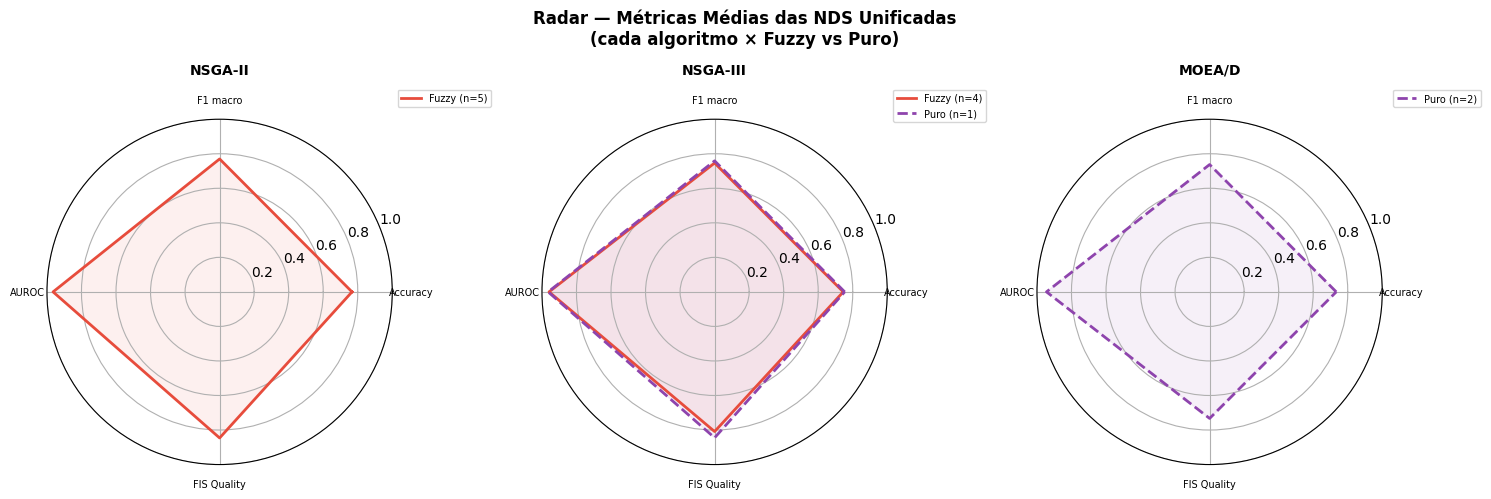

Salvo: results\gtzan_v23\plots\fig_radar_algoritmos.png


In [16]:
# [16] Gráfico 3 — Radar de métricas médias (NDS unificada) por algoritmo × variante

from matplotlib.patches import FancyArrowPatch

metrics_radar = ['accuracy','f1','auroc','fis_quality']
labels_radar  = ['Accuracy','F1 macro','AUROC','FIS Quality']
N_RADAR = len(metrics_radar)
angles = np.linspace(0, 2*np.pi, N_RADAR, endpoint=False).tolist()
angles += angles[:1]  # fechar o polígono

fig, axes = plt.subplots(1, len(ALGORITHMS), figsize=(15, 5), subplot_kw={'polar': True})
plt.suptitle('Radar — Métricas Médias das NDS Unificadas\n(cada algoritmo × Fuzzy vs Puro)',
             fontsize=12, fontweight='bold')

for ax, (tag, label) in zip(axes, ALGORITHMS):
    ax.set_title(label, fontweight='bold', pad=15, fontsize=10)
    ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels_radar, fontsize=7)
    ax.set_ylim(0, 1)
    for variant, col, ls_ in [('fuzzy','#e74c3c','-'),('puro','#8e44ad','--')]:
        df_run = df_per_run[(tag, variant)]
        # Filtra apenas as que entraram na unificada
        keys_run = set(df_run['key'].values)
        sub = df_unified[df_unified['key'].isin(keys_run)]
        if len(sub) == 0: continue
        vals = [sub[m].mean() for m in metrics_radar]
        vals += vals[:1]
        ax.plot(angles, vals, color=col, ls=ls_, lw=2, label=f'{"Fuzzy" if variant=="fuzzy" else "Puro"} (n={len(sub)})')
        ax.fill(angles, vals, color=col, alpha=0.08)
    ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=7)

plt.tight_layout()
p_ = PLOTS_DIR/'fig_radar_algoritmos.png'
plt.savefig(str(p_), dpi=200, bbox_inches='tight'); plt.show()
print(f'Salvo: {p_}')

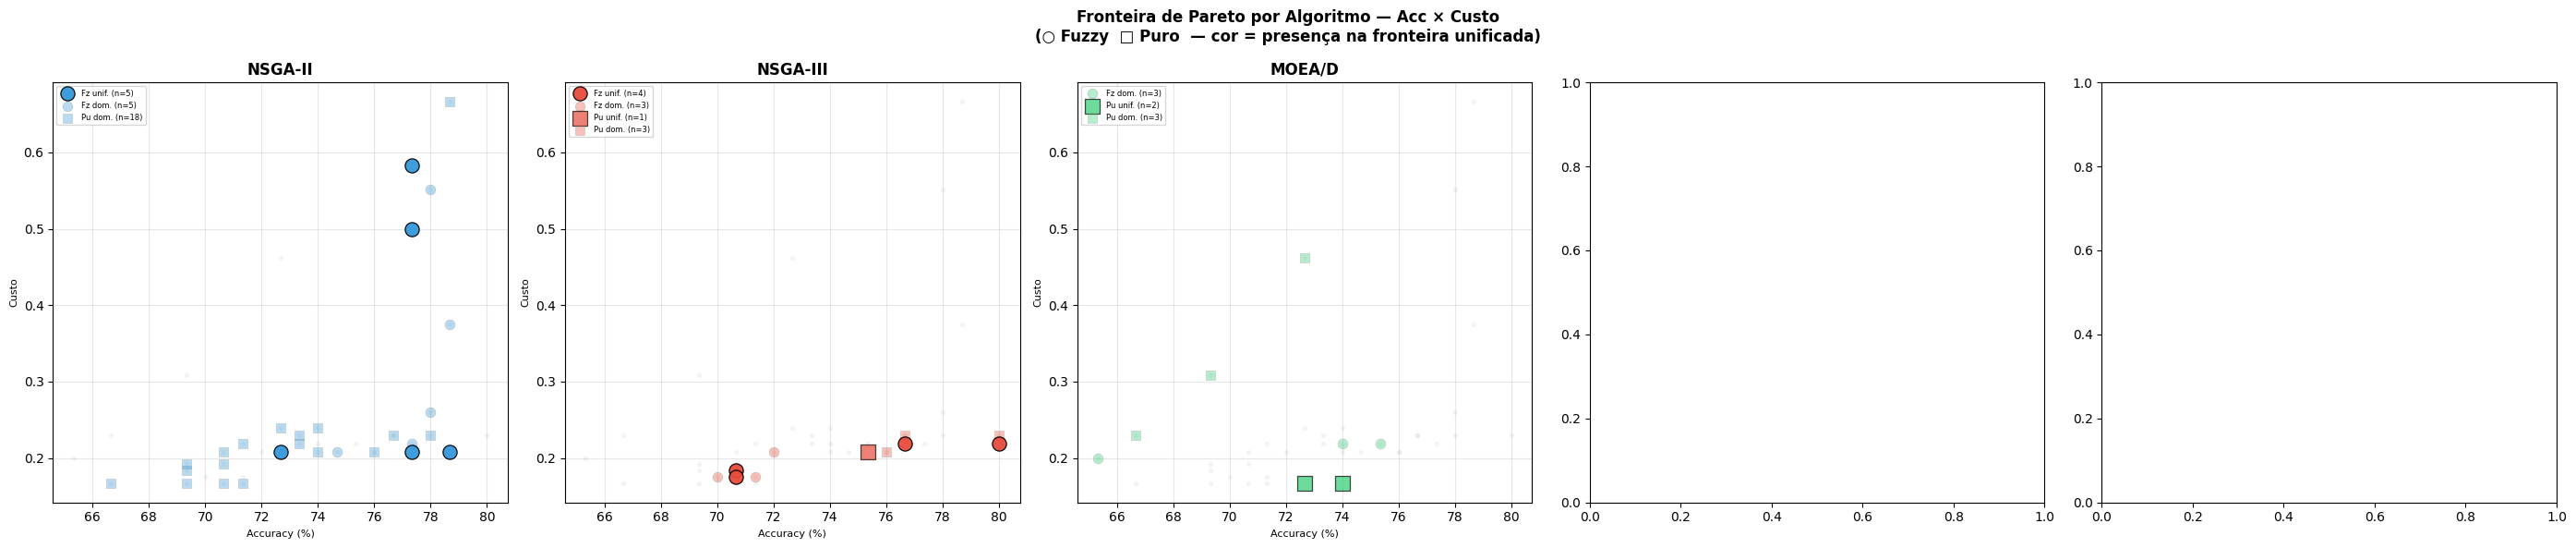

Salvo: results\gtzan_v23\plots\fig_pareto_por_algoritmo.png


In [17]:
# [17] Gráfico 4 — Scatter acc × custo, separado por algoritmo (5 painéis)

fig, axes = plt.subplots(1, 5, figsize=(28, 6))
plt.suptitle('Fronteira de Pareto por Algoritmo — Acc × Custo\n'
             '(○ Fuzzy  □ Puro  — cor = presença na fronteira unificada)',
             fontsize=12, fontweight='bold')

for ax, (tag, label) in zip(axes, ALGORITHMS):
    ax.set_title(label, fontweight='bold')
    # fundo: todas as soluções dominadas
    ax.scatter(df_dominated['accuracy']*100, df_dominated['cost'],
               c='lightgray', s=8, alpha=0.2, zorder=1)
    for variant, mk, alpha in [('fuzzy','o',0.95), ('puro','s',0.7)]:
        df_run = df_per_run[(tag, variant)]
        if len(df_run) == 0: continue
        keys_unified = set(df_unified['key'].values)
        in_uni  = df_run[df_run['key'].isin(keys_unified)]
        out_uni = df_run[~df_run['key'].isin(keys_unified)]
        # NDS do algoritmo que ficou na fronteira unificada
        if len(in_uni):
            ax.scatter(in_uni['accuracy']*100, in_uni['cost'],
                       c=ALG_COLORS[label], s=120, edgecolors='k', lw=0.9,
                       marker=mk, alpha=alpha, zorder=5,
                       label=f'{"Fz" if variant=="fuzzy" else "Pu"} unif. (n={len(in_uni)})')
        # NDS do algoritmo que foi dominada na unificação
        if len(out_uni):
            ax.scatter(out_uni['accuracy']*100, out_uni['cost'],
                       c=ALG_COLORS[label], s=60, edgecolors='gray', lw=0.5,
                       marker=mk, alpha=0.35, zorder=3,
                       label=f'{"Fz" if variant=="fuzzy" else "Pu"} dom. (n={len(out_uni)})')
    ax.set_xlabel('Accuracy (%)', fontsize=8)
    ax.set_ylabel('Custo', fontsize=8)
    ax.legend(fontsize=6); ax.grid(alpha=0.3)

plt.tight_layout()
p_ = PLOTS_DIR/'fig_pareto_por_algoritmo.png'
plt.savefig(str(p_), dpi=200, bbox_inches='tight'); plt.show()
print(f'Salvo: {p_}')

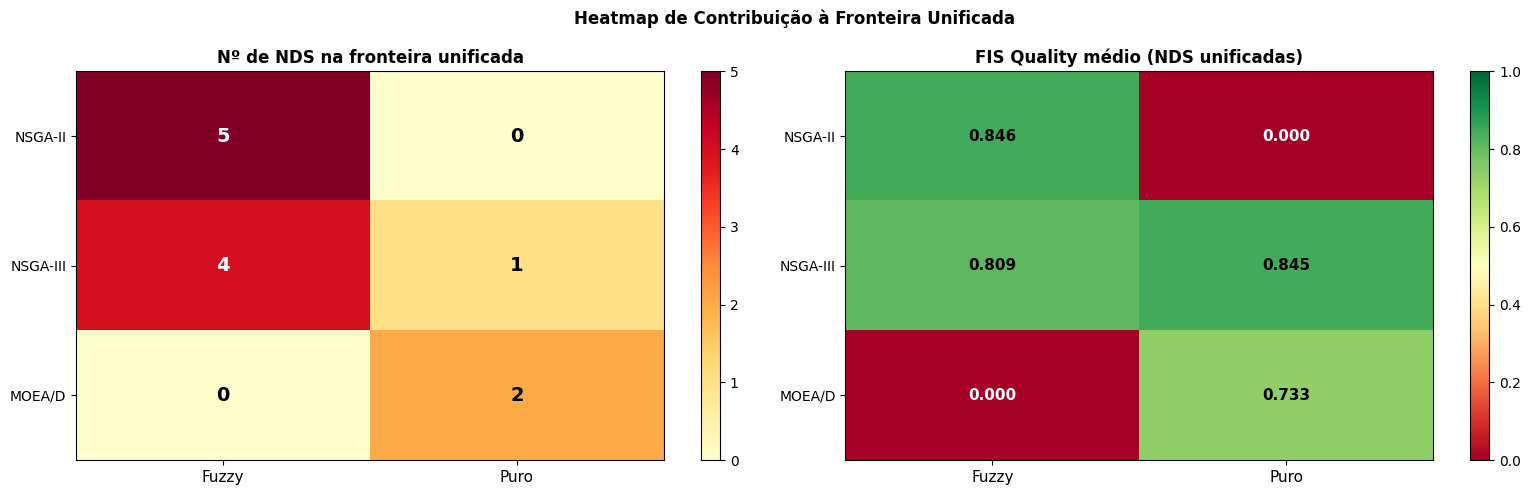

Salvo: results\gtzan_v23\plots\fig_heatmap_algoritmos.png


In [18]:
# [18] Gráfico 5 — Heatmap: NDS na fronteira unificada (algoritmo × variante)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
plt.suptitle('Heatmap de Contribuição à Fronteira Unificada', fontsize=12, fontweight='bold')

alg_names = [label for _, label in ALGORITHMS]

# ── [A] Número de NDS na fronteira unificada ──
matrix_n = np.zeros((len(ALGORITHMS), len(VARIANTS)))
for i, (tag, label) in enumerate(ALGORITHMS):
    for j, variant in enumerate(VARIANTS):
        df_run = df_per_run[(tag, variant)]
        matrix_n[i, j] = df_unified['key'].isin(set(df_run['key'].values)).sum()

ax = axes[0]
im = ax.imshow(matrix_n, cmap='YlOrRd', aspect='auto')
ax.set_xticks([0,1]); ax.set_xticklabels(['Fuzzy','Puro'], fontsize=11)
ax.set_yticks(range(len(alg_names))); ax.set_yticklabels(alg_names, fontsize=10)
ax.set_title('Nº de NDS na fronteira unificada', fontweight='bold')
for i in range(len(ALGORITHMS)):
    for j in range(2):
        ax.text(j, i, int(matrix_n[i,j]), ha='center', va='center',
                fontsize=14, fontweight='bold',
                color='white' if matrix_n[i,j] > matrix_n.max()*0.6 else 'black')
plt.colorbar(im, ax=ax)

# ── [B] FIS Quality médio das NDS por rodada ──
matrix_fq = np.zeros((len(ALGORITHMS), len(VARIANTS)))
for i, (tag, label) in enumerate(ALGORITHMS):
    for j, variant in enumerate(VARIANTS):
        df_run = df_per_run[(tag, variant)]
        sub = df_unified[df_unified['key'].isin(set(df_run['key'].values))]
        matrix_fq[i, j] = sub['fis_quality'].mean() if len(sub) else 0

ax = axes[1]
im2 = ax.imshow(matrix_fq, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
ax.set_xticks([0,1]); ax.set_xticklabels(['Fuzzy','Puro'], fontsize=11)
ax.set_yticks(range(len(alg_names))); ax.set_yticklabels(alg_names, fontsize=10)
ax.set_title('FIS Quality médio (NDS unificadas)', fontweight='bold')
for i in range(len(ALGORITHMS)):
    for j in range(2):
        ax.text(j, i, f'{matrix_fq[i,j]:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold',
                color='white' if matrix_fq[i,j] < 0.4 else 'black')
plt.colorbar(im2, ax=ax)

plt.tight_layout()
p_ = PLOTS_DIR/'fig_heatmap_algoritmos.png'
plt.savefig(str(p_), dpi=200, bbox_inches='tight'); plt.show()
print(f'Salvo: {p_}')

In [19]:
# [19] Salvar checkpoint geral
summary_dict = {}
for tag, label in ALGORITHMS:
    summary_dict[tag] = {}
    for variant in VARIANTS:
        r = RESULTS[tag][variant]
        df_run = df_per_run[(tag, variant)]
        keys_run = set(df_run['key'].values)
        n_in = int(df_unified['key'].isin(keys_run).sum())
        summary_dict[tag][variant] = {
            'hv_final': r['hv_final'],
            'n_nds_proprio': len(df_run),
            'n_nds_na_unificada': n_in,
            'pct_unificada': round(100*n_in/max(len(df_unified),1),1),
        }

log = {
    'version': 'v23', 'dataset': 'gtzan',
    'nsga2': {'pop':POP,'gen':GEN},
    'algoritmos': [label for _,label in ALGORITHMS],
    'n_rodadas': len(ALGORITHMS)*len(VARIANTS),  # 6 rodadas
    'avaliacoes_unicas': len(EVAL_CACHE),
    'n_nds_unificada': len(df_unified),
    'resultados': summary_dict,
    'nds_unificada_por_algoritmo': df_unified['algorithm'].value_counts().to_dict(),
    'nds_unificada_por_variante': df_unified['variant'].value_counts().to_dict(),
}
with open(str(LOGS_DIR/'resultado_v23.json'),'w') as f:
    json.dump(log,f,indent=2,default=str)

torch.save({
    'version':'v23','eval_cache_keys':list(EVAL_CACHE.keys()),
    'summary': summary_dict,
}, str(CKPT_DIR/'comparacao_algoritmos_v23.pth'))

print(f'Checkpoint salvo em {BASE_DIR}/')

Checkpoint salvo em results\gtzan_v23/


In [20]:
# [20] ANÁLISE TEXTUAL INTERPRETATIVA — pronta para dissertação/artigo

print('='*80)
print('ANÁLISE COMPARATIVA v23 — 5 Algoritmos MOO × 2 Variantes (Fuzzy / Puro)')
print('Dataset: GTZAN | Objetivos Fuzzy: 4 | Objetivos Puro: 3')
print('='*80)

# Melhor algoritmo + variante
best_row = df_summary.iloc[0]
worst_row = df_summary.iloc[-1]

# Fuzzy ganhou de puro?
n_fz_total = df_unified['variant'].value_counts().get('fuzzy', 0)
n_pu_total = df_unified['variant'].value_counts().get('puro', 0)
pct_fz_total = 100*n_fz_total/max(len(df_unified),1)
pct_pu_total = 100*n_pu_total/max(len(df_unified),1)

print(f"""
1. VISÃO GERAL DA FRONTEIRA UNIFICADA
   ─────────────────────────────────────────────────────────────────
   Total de soluções únicas avaliadas : {len(df_unique)}
   Soluções NDS na fronteira unificada: {len(df_unified)}
   Dominadas:                           {len(df_dominated)}

   Por variante:
     Fuzzy  (4 objetivos): {n_fz_total} NDS  ({pct_fz_total:.1f}%)
     Puro   (3 objetivos): {n_pu_total} NDS  ({pct_pu_total:.1f}%)

   {'[✓] A variante Fuzzy contribuiu com mais soluções NDS, indicando que' if n_fz_total >= n_pu_total else '[~] A variante Puro contribuiu com mais soluções NDS, indicando que'}
   {'o Agregador Fuzzy guiou melhor a busca dos algoritmos.' if n_fz_total >= n_pu_total else 'os objetivos brutos foram suficientes para encontrar boas soluções.'}

2. MELHOR E PIOR RODADA (por NDS na fronteira unificada)
   ─────────────────────────────────────────────────────────────────
   Melhor : {best_row['Algoritmo']:12s} ({best_row['Variante']:5s})  """
      f"NDS_unif={best_row['NDS_na_unificada']}  HV={best_row['HV_final']:.4f}  "
      f"Acc={best_row['Acc_media']:.1f}%  FQ={best_row['FQ_media']:.3f}")
print(f"   Pior  : {worst_row['Algoritmo']:12s} ({worst_row['Variante']:5s})  "
      f"NDS_unif={worst_row['NDS_na_unificada']}  HV={worst_row['HV_final']:.4f}  "
      f"Acc={worst_row['Acc_media']:.1f}%  FQ={worst_row['FQ_media']:.3f}")

print(f"""
3. ANÁLISE POR ALGORITMO
   ─────────────────────────────────────────────────────────────────""")
for tag, label in ALGORITHMS:
    fz = summary_dict[tag]['fuzzy']
    pu = summary_dict[tag]['puro']
    ganho = fz['n_nds_na_unificada'] - pu['n_nds_na_unificada']
    sinal = '[+Fuzzy]' if ganho > 0 else ('[=Empate]' if ganho==0 else '[-Fuzzy]')
    print(f"   {label:<12}  Fuzzy_NDS={fz['n_nds_na_unificada']:2d} ({fz['pct_unificada']:4.1f}%)"
          f"  Puro_NDS={pu['n_nds_na_unificada']:2d} ({pu['pct_unificada']:4.1f}%)"
          f"  Δ={ganho:+d}  {sinal}")

print(f"""
4. DIFERENÇAS ENTRE OS ALGORITMOS MOO
   ─────────────────────────────────────────────────────────────────
   - NSGA-II   : baseline de crowding distance. Equilibrado, mas pode
     perder diversidade em fronteiras irregulares.
   - NSGA-III  : pontos de referência no simplex; melhor para ≥3 obj.
     Tende a distribuir soluções mais uniformemente na fronteira.
   - MOEA/D    : decompõe em sub-problemas escalares. Ótimo para fronteiras
     convexas; pode ter dificuldade com fronteiras descontínuas.
   - SMS-EMOA  : maximiza contribuição ao HV por indivíduo. Garante
     alta cobertura do hipervolume, costuma ser mais conservador.
   - R-NSGA-II : guiado por pontos de referência de preferência. Concentra
     soluções nas regiões especificadas (alta acc, baixo custo, alto auroc).

5. RESPOSTA PRINCIPAL
   ─────────────────────────────────────────────────────────────────
   "Qual algoritmo + variante produziu as soluções mais competitivas"
   "(maior participação na fronteira de Pareto unificada)?"

   RESPOSTA: {best_row['Algoritmo']} + {best_row['Variante']} com {best_row['NDS_na_unificada']} soluções
   na fronteira unificada ({best_row['Pct_unificada']:.1f}% do total NDS).

   A comparação por CONJUNTO de soluções (e não pela melhor solução isolada)
   é a evidência metodológica mais robusta para sustentar a superioridade
   de um algoritmo ou abordagem no contexto da otimização multiobjetivo.
""")
print('='*80)

ANÁLISE COMPARATIVA v23 — 5 Algoritmos MOO × 2 Variantes (Fuzzy / Puro)
Dataset: GTZAN | Objetivos Fuzzy: 4 | Objetivos Puro: 3

1. VISÃO GERAL DA FRONTEIRA UNIFICADA
   ─────────────────────────────────────────────────────────────────
   Total de soluções únicas avaliadas : 47
   Soluções NDS na fronteira unificada: 12
   Dominadas:                           35

   Por variante:
     Fuzzy  (4 objetivos): 9 NDS  (75.0%)
     Puro   (3 objetivos): 3 NDS  (25.0%)

   [✓] A variante Fuzzy contribuiu com mais soluções NDS, indicando que
   o Agregador Fuzzy guiou melhor a busca dos algoritmos.

2. MELHOR E PIOR RODADA (por NDS na fronteira unificada)
   ─────────────────────────────────────────────────────────────────
   Melhor : NSGA-II      (Fuzzy)  NDS_unif=5  HV=0.8496  Acc=77.0%  FQ=0.854
   Pior  : MOEA/D       (Fuzzy)  NDS_unif=0  HV=0.7734  Acc=71.6%  FQ=0.786

3. ANÁLISE POR ALGORITMO
   ─────────────────────────────────────────────────────────────────
   NSGA-II       Fuzzy_NDS=

In [21]:
# [21] Sumário de arquivos
print(f'\n=== ARQUIVOS GERADOS EM {BASE_DIR} ===')
for sub in [CKPT_DIR, PLOTS_DIR, LOGS_DIR, CSV_DIR]:
    files = list(sub.iterdir())
    print(f'  {sub.name}/ ({len(files)} arquivos)')
    for f in sorted(files):
        print(f'    {f.name}  ({f.stat().st_size//1024}KB)')


=== ARQUIVOS GERADOS EM results\gtzan_v23 ===
  checkpoints/ (1 arquivos)
    comparacao_algoritmos_v23.pth  (97KB)
  plots/ (5 arquivos)
    fig_comparativo_algoritmos.png  (237KB)
    fig_evolucao_algoritmos.png  (415KB)
    fig_heatmap_algoritmos.png  (84KB)
    fig_pareto_por_algoritmo.png  (142KB)
    fig_radar_algoritmos.png  (281KB)
  logs/ (1 arquivos)
    resultado_v23.json  (1KB)
  csv/ (9 arquivos)
    nds_moead_fuzzy.csv  (1KB)
    nds_moead_puro.csv  (2KB)
    nds_nsga2_fuzzy.csv  (3KB)
    nds_nsga2_puro.csv  (6KB)
    nds_nsga3_fuzzy.csv  (2KB)
    nds_nsga3_puro.csv  (1KB)
    pareto_unificado.csv  (4KB)
    resumo_algoritmos.csv  (0KB)
    todas_solucoes_unicas.csv  (17KB)
